In [2]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

In [3]:
# open text file to get a list of the .fits files we need to load in
fits_filepath = 'fits_files/'
text_file = 'wget_strings.txt'
test_file_df = pd.read_csv(fits_filepath+text_file, header=None, names=['filepath'])
test_file_df

,filepath
0,3590/spec-3590-55201-0554.fits
1,3662/spec-3662-55182-0546.fits
2,3663/spec-3663-55176-0766.fits
3,3667/spec-3667-55186-0806.fits
4,3670/spec-3670-55480-0196.fits
...,...
1381,11650/spec-11650-58508-0660.fits
1382,11651/spec-11651-58511-0742.fits
1383,11678/spec-11678-58511-0672.fits
1384,11678/spec-11678-58511-0785.fits


In [87]:
with fits.open('fits_files/3590/spec-3590-55201-0554.fits') as hdul:
    # flux
    flux_density_factor = hdul['COADD'].data['flux']       # 10^-17 * [ergs / s / cm^2 / A]
    flux_density = 10**(-17) * flux_density_factor         # [ergs / s / cm^2 / A]
    rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift

    # flux error
    ivar = hdul['COADD'].data['ivar']
    flux_density_err = np.zeros_like(flux_density)
    good = ivar > 0    # avoid dividing by zero
    flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
    rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift

    # wavelength
    log_wav = hdul['COADD'].data['loglam']
    wavelength = 10**log_wav                  # [A]
    rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift

    print(len(rest_flux_density))

    #mask
    and_mask = hdul['COADD'].data['or_mask']
    bad_mask = (and_mask != 0)
    
    print(len(rest_flux_density[bad_mask]))
    flux = rest_flux_density[bad_mask]
    wav = rest_wavelength[bad_mask]

4610
2195


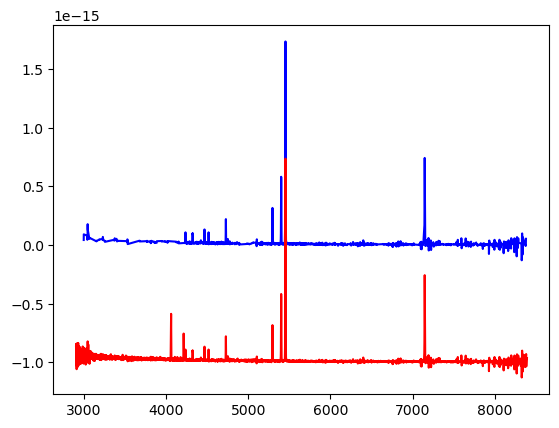

In [89]:
plt.figure()
plt.plot(wav, flux, color='blue')
plt.plot(rest_wavelength, rest_flux_density - 1e-15, color='red')
plt.show()

In [ ]:
source_ID = []
wavelengths = []
fluxes = []
flux_errs = []
for filepath in test_file_df['filepath']:
    ID_string = filepath.split('/')[-1].split('.')[0][5:]  # saving the PLATE-MJD-FIBERID portion of filepath as a string
    source_ID.append(ID_string)

    try:

        with fits.open(fits_filepath+filepath) as hdul:
            # ----------- Recovering Z value --------------
            zdata = hdul[2].data
            z = zdata['Z']

            # ----------- saving spectral data ------------

            # flux
            flux_density_factor = hdul['COADD'].data['flux']       # 10^-17 * [ergs / s / cm^2 / A]
            flux_density = 10**(-17) * flux_density_factor         # [ergs / s / cm^2 / A]
            rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift

            # flux error
            ivar = hdul['COADD'].data['ivar']
            flux_density_err = np.zeros_like(flux_density)
            good = ivar > 0    # avoid dividing by zero
            flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
            rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift

            # wavelength
            log_wav = hdul['COADD'].data['loglam']
            wavelength = 10**log_wav                  # [A]
            rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift

            # #mask
            # and_mask = hdul['COADD'].data['and_mask']
            # bad_mask = (and_mask != 0)
            
            # fluxes.append(rest_flux_density[bad_mask])
            # flux_errs.append(rest_flux_density_err[bad_mask]) 
            # wavelengths.append(rest_wavelength[bad_mask])

            fluxes.append(rest_flux_density)
            flux_errs.append(rest_flux_density_err) 
            wavelengths.append(rest_wavelength)

            # ----------------------------------------------

    # if unable to find spectra (maybe we weren't able to retrieve it with wget...), give exception and save NaN values
    except Exception as e:
        print(f"No spectrum found for filepath: {filepath}")
        print(e)

        # input null values so that the length of our arrays match the number of sources in our text file
        fluxes.append(None)
        flux_errs.append(None)
        wavelengths.append(None)


In [ ]:
# source_ID = []
# wavelengths = []
# fluxes = []
# flux_errs = []

# # 3590/spec-3590-55201-0554.fits

# # for filepath in test_file_df['filepath']:
# for i in range(0, 1):
#     filepath = test_file_df['filepath'][i]
#     ID_string = filepath.split('/')[-1].split('.')[0][5:]  # saving the PLATE-MJD-FIBERID portion of filepath as a string
#     source_ID.append(ID_string)
#     print(ID_string)
#     # z = data['Z']/\\\

#     try:

#         with fits.open(fits_filepath+filepath) as hdul:
#             # ----------- Recovering Z value --------------
#             zdata = hdul[2].data
#             z = zdata['Z']
#             print(z)
#             # print(repr(hdul[1].data))
#             # print(hdul.info())
#             # data = hdul[1].data
#             # print(hdul[2].get)
#             # print(hdul['COADD'].data['Z'])
#             # print(hdul[0].header)

#             # ----------- saving spectral data ------------

#             # flux
#             flux_density_factor = hdul['COADD'].data['flux']       # 10^-17 * [ergs / s / cm^2 / A]
#             flux_density = 10**(-17) * flux_density_factor         # [ergs / s / cm^2 / A]
#             # rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift
#             # fluxes.append(rest_flux_density)

#             # flux error
#             ivar = hdul['COADD'].data['ivar']
#             flux_density_err = np.zeros_like(flux_density)
#             good = ivar > 0    # avoid dividing by zero
#             flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
#             flux_errs.append(flux_density_err)
#             # rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift
#             # flux_errs.append(rest_flux_density_err)  # ... saving these data

#             # wavelength
#             log_wav = hdul['COADD'].data['loglam']
#             print(log_wav)
#             wavelength = 10**log_wav                  # [A]
#             print(wavelength)
#             rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift
#             print(rest_wavelength)
#             wavelengths.append(rest_wavelength)

#             # ----------------------------------------------

#     # if unable to find spectra (maybe we weren't able to retrieve it with wget...), give exception and save NaN values
#     except Exception as e:
#         print(f"No spectrum found for filepath: {filepath}")
#         print(e)

#         # input null values so that the length of our arrays match the number of sources in our text file
#         fluxes.append(None)
#         flux_errs.append(None)
#         wavelengths.append(None)


3590-55201-0554
[0.34467775]
[3.5546 3.5547 3.5548 ... 4.0153 4.0154 4.0155]
[ 3585.915   3586.74    3587.5671 ... 10358.569  10360.958  10363.348 ]
[2666.7468 2667.3604 2667.9756 ... 7703.385  7705.161  7706.938 ]


In [69]:
# save this data to a dataframe
df = pd.DataFrame()
df['ID'] = source_ID
df['WAVELENGTH'] = wavelengths
df['FLUX'] = fluxes
df['FLUX_ERR'] = flux_errs
df

,ID,WAVELENGTH,FLUX,FLUX_ERR
0,3590-55201-0554,"[2666.7468, 2667.3604, 2667.9756, 2668.589, 26...","[1.5376116e-16, 1.7065423e-16, 3.618697e-17, -...","[6.45998e-17, 6.5603866e-17, 6.168468e-17, 5.7..."
1,3662-55182-0546,"[2963.5466, 2964.2285, 2964.9119, 2965.594, 29...","[-4.8560505e-17, 5.010395e-17, 3.424098e-17, 8...","[1.9204293e-17, 1.9529362e-17, 1.9772642e-17, ..."
2,3663-55176-0766,"[3321.7466, 3322.5125, 3323.277, 3324.0432, 33...","[1.0512349e-18, -3.1325836e-17, 1.0429514e-17,...","[3.8411243e-17, 3.8148782e-17, 3.697119e-17, 3..."
3,3667-55186-0806,"[2515.716, 2516.296, 2516.875, 2517.4553, 2518...","[7.921987e-17, 2.959126e-17, 2.670676e-17, 2.0...","[4.9695095e-17, 4.8902157e-17, 4.6883148e-17, ..."
4,3670-55480-0196,"[3338.9468, 3339.715, 3340.485, 3341.2537, 334...","[8.8378136e-18, -7.1479774e-17, -6.7627876e-20...","[3.506152e-17, 3.1611174e-17, 3.2947464e-17, 3..."
...,...,...,...,...
1381,11650-58508-0660,"[2790.284, 2790.9275, 2791.5696, 2792.2134, 27...","[4.1232952e-17, -4.350524e-17, -2.8342073e-17,...","[3.514363e-17, 3.204651e-17, 3.126412e-17, 3.5..."
1382,11651-58511-0742,"[2617.0322, 2617.634, 2618.2378, 2618.84, 2619...","[2.4607857e-17, -2.7592394e-18, -3.0117927e-17...","[5.6741903e-17, 0.0, 5.2263776e-17, 5.0965453e..."
1383,11678-58511-0672,"[3434.5835, 3435.3757, 3436.1658, 3436.9583, 3...","[1.2226359e-17, 2.26183e-17, -3.4800382e-17, 4...","[1.1251327e-16, 5.0332302e-17, 4.7100306e-17, ..."
1384,11678-58511-0785,"[2297.8267, 2298.3552, 2298.8853, 2299.414, 22...","[-3.5774797e-17, -5.22128e-17, -6.863853e-17, ...","[7.090551e-17, 0.0, 7.2179635e-17, 6.568765e-1..."


In [70]:
# saving to a .pkl file 
df.to_pickle('eBOSS_spectra.pkl')

In [ ]:
# load in this csv file into your main notebook for plotting spectra
# may want to match 'ID' column with 'PMF_STRING' in Owen's catalog (eBOSS spectral measurements table) to get redshift (and other) measurements ...
# then convert the spectra from observed frame to rest frame!

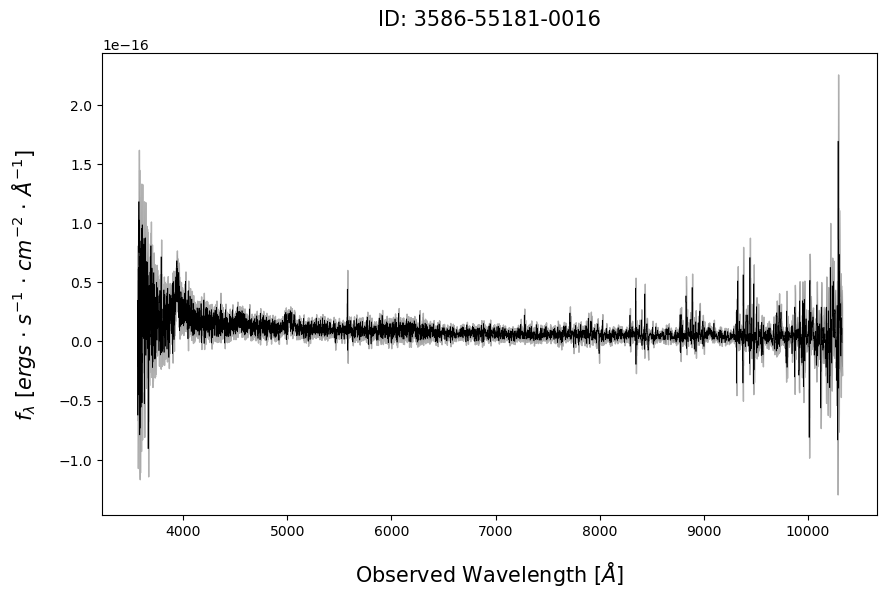

In [35]:
# plot a source from dataframe to check validity
index = 0  # choose any index value

# initializing our figure
plt.figure(figsize=(10,6))

# labeling our axes
plt.title(f"ID: {df['ID'].iloc[index]}",fontsize=15, pad=20)
plt.xlabel(r'Observed Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# main spectral data
plt.step(df['WAVELENGTH'].iloc[index], df['FLUX'].iloc[index], where='mid', color='black', linewidth=0.5)

# flux errors shown by shaded region
upper = df['FLUX'].iloc[index] + df['FLUX_ERR'].iloc[index]
lower = df['FLUX'].iloc[index] - df['FLUX_ERR'].iloc[index]
plt.fill_between(df['WAVELENGTH'].iloc[index], lower, upper, color='black', alpha=0.3)

# saving and displaying figure
fig_name = f'{df['ID'].iloc[index]}_spectrum.png'  # name the figure
# file_path = os.path.join('..', 'plots', fig_name)
# plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()